# Module 1 In-Class Lab: Getting Started with Text Data

This introductory lab uses a small collection of transit reviews to practice the first steps in a text-data workflow: loading a dataset, understanding its structure, summarizing categories, and comparing groups. The dataset combines **unstructured text** in `review_text` with **structured variables** such as route, rating, delay, and issue type.

## Learning objectives

By the end of the lab, you should be able to:

- load a CSV file into a pandas DataFrame;
- inspect a dataset's dimensions, columns, data types, and missing values;
- count observations within a categorical variable;
- group observations and calculate a summary statistic; and
- create simple bar charts that communicate patterns in the data.

**Suggested workflow:** Run the notebook from top to bottom. Before moving to the next section, describe the output in plain language and answer each checkpoint.

## 0. Environment setup

The notebook uses **pandas** to work with tabular data and **Matplotlib** to create charts. If you are working in Google Colab, mount Google Drive before loading the dataset so that `/content/drive/MyDrive/` is available.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Part I. Load the transit-review data

`your_path` stores the shared portion of the Google Drive location. The f-string appends the course-specific folders and file name without repeating the full path. `pd.read_csv()` reads the CSV file and stores it as a DataFrame named `df`.

If the next cell raises a `FileNotFoundError`, first confirm that Google Drive is mounted and that `your_path` points to the folder containing `DSA495-2026`.

In [3]:
your_path = "/content/drive/MyDrive/a-ncsu-courses/"
df = pd.read_csv(f"{your_path}DSA495-2026/Data/M01_Introduction/transit_reviews.csv")

# Part II. Preview the data

Displaying `df` provides a first look at the observations and variables. Each **row** represents one transit review, while each **column** records one feature of that review. Notice that `review_text` contains the language we may eventually analyze, while the other columns provide useful context and labels.

**Checkpoint 1:** Which columns contain numerical measurements, which contain categories or identifiers, and which contain free-form text?

In [ ]:
df

,review_id,date,route,rating,delay_minutes,issue_type,review_text
0,1001,2026-08-01,7,2,18,Delay,The bus arrived much later than expected.
1,1002,2026-08-01,12,5,0,Praise,The driver was kind and helpful.
2,1003,2026-08-02,7,1,25,Information,The app showed the wrong arrival time.
3,1004,2026-08-02,3,4,3,Cleanliness,The bus was clean and comfortable.
4,1005,2026-08-03,12,2,15,Crowding,The bus was too crowded to find a seat.
5,1006,2026-08-03,3,5,0,Praise,The trip was quick and easy.
6,1007,2026-08-04,7,3,8,Delay,The bus was a little late today.
7,1008,2026-08-04,12,1,30,Cancellation,My scheduled bus never arrived.
8,1009,2026-08-05,3,4,2,Accessibility,The ramp made boarding easy.
9,1010,2026-08-05,7,2,12,Crowding,The bus was crowded and uncomfortable.


# Part III. Inspect the DataFrame

Before analyzing a dataset, verify its size and structure. The checks below help catch problems such as missing columns, unexpected data types, or an incomplete file.

### 3.1 Rows and columns

`df.shape` returns a tuple in the form `(number of rows, number of columns)`.

In [ ]:
df.shape

(10, 7)

### 3.2 Column names

`df.columns` lists the variable names exactly as pandas stores them. Checking these names prevents spelling and capitalization errors in later code.

In [ ]:
df.columns

Index(['review_id', 'date', 'route', 'rating', 'delay_minutes', 'issue_type',
       'review_text'],
      dtype='object')

### 3.3 Data types and missing values

`df.info()` reports each column's data type and non-null count. A non-null count smaller than the total number of rows signals missing values. In pandas, text columns are commonly reported as `object` unless they have been converted to a dedicated string type.

**Checkpoint 2:** Does every column contain the expected number of non-null values? Which columns might need type conversion before a more detailed analysis?

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   review_id      10 non-null     int64 
 1   date           10 non-null     object
 2   route          10 non-null     int64 
 3   rating         10 non-null     int64 
 4   delay_minutes  10 non-null     int64 
 5   issue_type     10 non-null     object
 6   review_text    10 non-null     object
dtypes: int64(4), object(3)
memory usage: 692.0+ bytes


# Part IV. Count reviews by issue type

`value_counts()` counts how often each category appears in `issue_type`. Calling `.plot(kind="bar")` turns those counts into a bar chart, and `plt.ylabel()` adds a readable axis label.

This is a **frequency summary**: it tells us what kinds of issues appear most often in this small dataset, but it does not explain why they occur.

**Checkpoint 3:** Which issue types appear most often? What additional data would you want before treating this pattern as representative of the full transit system?

Text(0, 0.5, 'Number of Reviews')

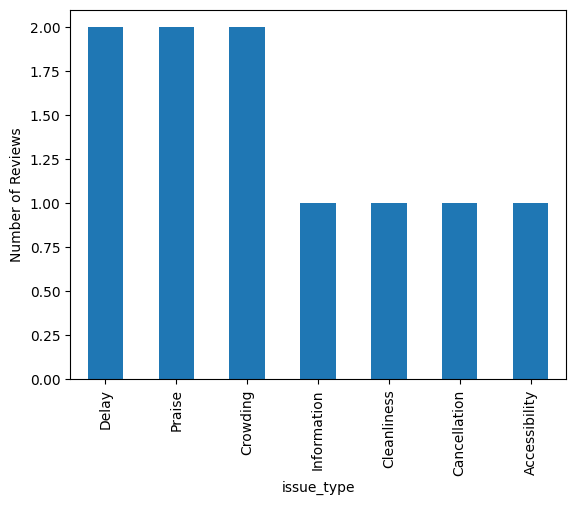

In [ ]:
df["issue_type"].value_counts().plot(kind="bar")
plt.ylabel("Number of Reviews")

# Part V. Compare average delays by route

The expression below groups reviews by `route`, selects `delay_minutes`, and calculates the mean for each group. The bar chart makes the route-level averages easier to compare.

An average summarizes the observations in each group, but it can be unstable when a group contains only a few reviews. Always examine the number and spread of observations before drawing a strong conclusion.

**Checkpoint 4:** Which route has the highest average reported delay? Does the dataset contain enough reviews per route to support a confident comparison?

Text(0, 0.5, 'Average Delay in Minutes')

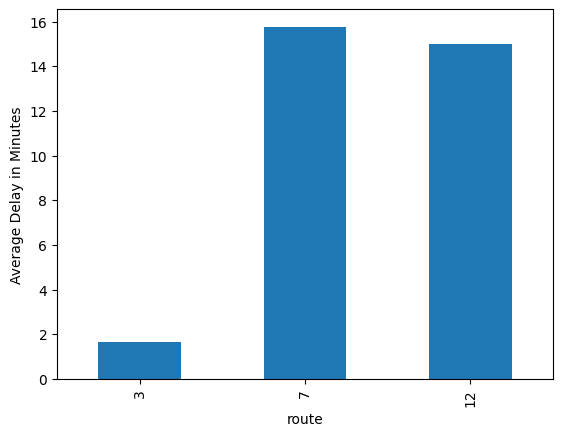

In [ ]:
df.groupby("route")["delay_minutes"].mean().plot(kind="bar")
plt.ylabel("Average Delay in Minutes")


# Wrap-up

This notebook followed a compact exploratory workflow:

1. load the dataset;
2. preview the observations;
3. verify dimensions, columns, data types, and completeness;
4. summarize a categorical variable; and
5. compare a numerical variable across groups.

These checks establish the context needed for later text analysis. Before modeling `review_text`, we need to understand what each row represents, how the text relates to the structured variables, and whether the sample supports the conclusions we want to make.